In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, brier_score_loss

import sys
sys.path.append('..')
from src.features.build_features import build_features

pd.set_option('display.max_columns', 200)
sns.set_style("whitegrid")

DATA_PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")

# Load the model artifacts
model = lgb.Booster(model_file=str(MODELS_DIR / "lgb_tuned.txt"))
calibrator = joblib.load(MODELS_DIR / "isotonic_calibrator.pkl")
metadata = joblib.load(MODELS_DIR / "metadata.pkl")

print("Model loaded")
print(f"Best iteration: {metadata['best_iteration']}")
print(f"Test AUC: {metadata['metrics']['test_auc']:.4f}")
print(f"Test Brier (calibrated): {metadata['metrics']['test_brier_calibrated']:.4f}")

Model loaded
Best iteration: 1085
Test AUC: 0.7666
Test Brier (calibrated): 0.0665


In [2]:
# Load the test set
test = pd.read_parquet(DATA_PROCESSED / "test.parquet")
test = build_features(test)

# Apply categorical dtypes
for col in metadata['categorical_cols']:
    test[col] = test[col].astype('category')

# Use the exact feature list from training
X_test = test[metadata['feature_cols']]
y_test = test['TARGET']

# Predict: raw then calibrated
pd_raw = model.predict(X_test)
pd_cal = calibrator.predict(pd_raw)

print(f"Test set: {len(test):,} applications")
print(f"Default rate: {y_test.mean():.4f}")
print(f"Mean calibrated PD: {pd_cal.mean():.4f}")

Test set: 46,127 applications
Default rate: 0.0792
Mean calibrated PD: 0.0807


In [3]:
# Business assumptions
LGD = 0.65                    # loss given default (fraction of exposure)
PROFIT_MARGIN = 0.10          # profit per good loan (fraction of principal)
REVIEW_COST = 0.005           # cost of manual review (fraction of principal)
REVIEW_CAPACITY = 0.05        # top 5% reviewed
EAD = 100_000                 # exposure at default (avg loan amount)

# Derived per-loan economics
loss_if_default = LGD * EAD                  # $65,000
profit_if_repaid = PROFIT_MARGIN * EAD       # $10,000
review_cost_abs = REVIEW_COST * EAD          # $500

print(f"Loss if default:     ${loss_if_default:>10,.0f}")
print(f"Profit if repaid:    ${profit_if_repaid:>10,.0f}")
print(f"Cost of review:      ${review_cost_abs:>10,.0f}")
print(f"Review capacity:     {REVIEW_CAPACITY*100:.1f}% of applications")

Loss if default:     $    65,000
Profit if repaid:    $    10,000
Cost of review:      $       500
Review capacity:     5.0% of applications


In [4]:
# Break-even PD: at what probability of default are we indifferent?
# Expected profit = (1-PD) * PROFIT - PD * LOSS
# Set to zero and solve: PD* = PROFIT / (PROFIT + LOSS)
break_even_pd = profit_if_repaid / (profit_if_repaid + loss_if_default)

print(f"Break-even PD: {break_even_pd:.4f}")
print(f"Any applicant with PD above this should be rejected (in the simple case).")

Break-even PD: 0.1333
Any applicant with PD above this should be rejected (in the simple case).


In [5]:
def compute_policy_pnl(pd_array, y_true, threshold=None, policy_name=""):
    """
    Compute total P&L for a simple approve/reject policy at a given threshold.
    No review option.
    """
    if threshold is None:
        # Approve all
        approve = np.ones(len(pd_array), dtype=bool)
    elif threshold > 1:
        # Reject all
        approve = np.zeros(len(pd_array), dtype=bool)
    else:
        approve = pd_array < threshold

    n_approved = approve.sum()
    n_rejected = (~approve).sum()

    # Among approved: those who repaid = profit; those who defaulted = loss
    approved_outcomes = y_true[approve]
    n_repaid = (approved_outcomes == 0).sum()
    n_default = (approved_outcomes == 1).sum()

    total_profit = n_repaid * profit_if_repaid
    total_loss = n_default * loss_if_default
    net_pnl = total_profit - total_loss

    return {
        'policy': policy_name,
        'n_approved': int(n_approved),
        'approval_rate': n_approved / len(pd_array),
        'n_repaid': int(n_repaid),
        'n_default': int(n_default),
        'total_profit': total_profit,
        'total_loss': total_loss,
        'net_pnl': net_pnl
    }

policies = [
    compute_policy_pnl(pd_cal, y_test.values, threshold=None, policy_name="Approve all"),
    compute_policy_pnl(pd_cal, y_test.values, threshold=2.0,  policy_name="Reject all"),
    compute_policy_pnl(pd_cal, y_test.values, threshold=0.50, policy_name="Threshold @ 0.50 (naive)"),
    compute_policy_pnl(pd_cal, y_test.values, threshold=break_even_pd, policy_name=f"Threshold @ break-even ({break_even_pd:.3f})"),
]

df_policies = pd.DataFrame(policies)
df_policies['approval_rate'] = (df_policies['approval_rate'] * 100).round(2)
df_policies['net_pnl'] = df_policies['net_pnl'].apply(lambda x: f"${x:,.0f}")
df_policies['total_profit'] = df_policies['total_profit'].apply(lambda x: f"${x:,.0f}")
df_policies['total_loss'] = df_policies['total_loss'].apply(lambda x: f"${x:,.0f}")

print(df_policies[['policy', 'approval_rate', 'total_profit', 'total_loss', 'net_pnl']].to_string(index=False))

                        policy  approval_rate total_profit   total_loss      net_pnl
                   Approve all         100.00 $424,760,000 $237,315,000 $187,445,000
                    Reject all           0.00           $0           $0           $0
      Threshold @ 0.50 (naive)          99.62 $423,930,000 $231,465,000 $192,465,000
Threshold @ break-even (0.133)          83.50 $365,830,000 $125,775,000 $240,055,000


Optimal threshold: 0.1400
Max net P&L:      $240,055,000
Approval rate:    83.50%
False negatives:  1,935 (approvals that default)
False positives:  5,893 (rejections that would repay)


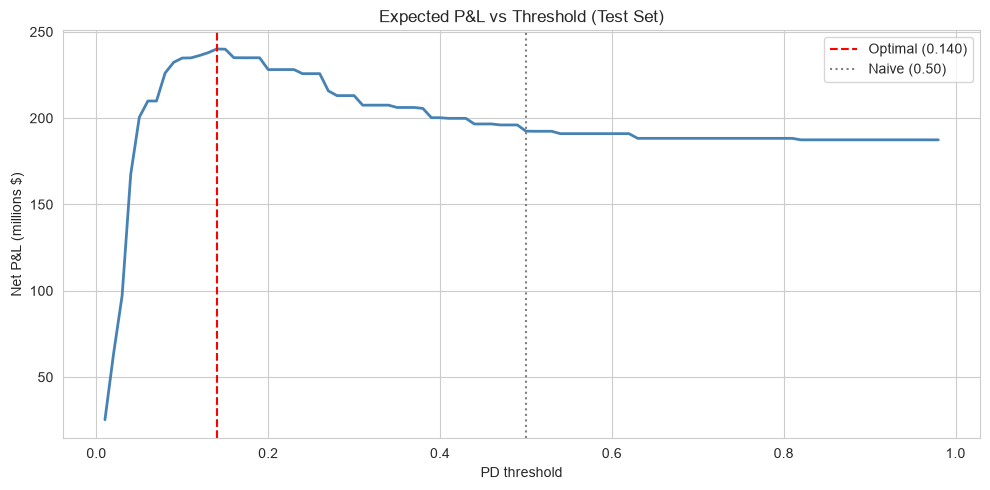

In [6]:
thresholds = np.arange(0.01, 0.99, 0.01)
results = []

for t in thresholds:
    p = compute_policy_pnl(pd_cal, y_test.values, threshold=t, policy_name=f"t={t:.2f}")
    p['threshold'] = t
    results.append(p)

sweep_df = pd.DataFrame(results)

best_idx = sweep_df['net_pnl'].idxmax()
best_row = sweep_df.loc[best_idx]

print(f"Optimal threshold: {best_row['threshold']:.4f}")
print(f"Max net P&L:      ${best_row['net_pnl']:,.0f}")
print(f"Approval rate:    {best_row['approval_rate']*100:.2f}%")
print(f"False negatives:  {best_row['n_default']:,} (approvals that default)")
print(f"False positives:  {(~((pd_cal < best_row['threshold'])) & (y_test.values==0)).sum():,} (rejections that would repay)")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep_df['threshold'], sweep_df['net_pnl'] / 1e6, color='steelblue', linewidth=2)
ax.axvline(best_row['threshold'], color='red', linestyle='--', label=f"Optimal ({best_row['threshold']:.3f})")
ax.axvline(0.5, color='gray', linestyle=':', label="Naive (0.50)")
ax.set_xlabel('PD threshold')
ax.set_ylabel('Net P&L (millions $)')
ax.set_title('Expected P&L vs Threshold (Test Set)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('../reports/figures/threshold_sweep.png', dpi=100, bbox_inches='tight')
plt.show() 

In [7]:
def compute_three_way_policy(pd_array, y_true, low_thresh, high_thresh, review_capacity):
    """
    Approve if PD < low_thresh
    Reject if PD > high_thresh
    Review if between — but capped at review_capacity (top-N by PD)
    Reviewed cases: assume reviewer correctly rejects defaulters and approves non-defaulters
    (best case for illustration; more complex modeling possible)
    """
    n = len(pd_array)
    n_review_max = int(n * review_capacity)

    in_review_band = (pd_array >= low_thresh) & (pd_array <= high_thresh)

    # If more in band than capacity, review the highest-PD ones
    if in_review_band.sum() > n_review_max:
        review_pd = pd_array.copy()
        review_pd[~in_review_band] = -1
        top_review_idx = np.argsort(review_pd)[::-1][:n_review_max]
        reviewed = np.zeros(n, dtype=bool)
        reviewed[top_review_idx] = True
    else:
        reviewed = in_review_band.copy()

    approved = (pd_array < low_thresh) & (~reviewed)
    rejected = (~approved) & (~reviewed)

    # Among approved: paid off -> profit, defaulted -> loss
    app_outcomes = y_true[approved]
    n_app_repaid = (app_outcomes == 0).sum()
    n_app_default = (app_outcomes == 1).sum()

    # Among reviewed: reviewer resolves correctly (best case)
    rev_outcomes = y_true[reviewed]
    n_rev_repaid = (rev_outcomes == 0).sum()
    n_rev_default = (rev_outcomes == 1).sum()

    # Reviewer rejects defaulters, approves non-defaulters
    profit = (n_app_repaid + n_rev_repaid) * profit_if_repaid
    loss = (n_app_default) * loss_if_default  # Only approved-and-defaulted count
    review_cost = reviewed.sum() * review_cost_abs

    net_pnl = profit - loss - review_cost

    return {
        'low_thresh': low_thresh,
        'high_thresh': high_thresh,
        'n_approved': int(approved.sum()),
        'n_reviewed': int(reviewed.sum()),
        'n_rejected': int(rejected.sum()),
        'n_defaults_approved': int(n_app_default),
        'profit': profit,
        'loss': loss,
        'review_cost': review_cost,
        'net_pnl': net_pnl
    }

# Try a few threshold combos
print("Three-way policy comparison:")
for low, high in [(0.05, 0.25), (0.08, 0.30), (0.10, 0.35), (0.05, 0.40)]:
    r = compute_three_way_policy(pd_cal, y_test.values, low, high, REVIEW_CAPACITY)
    print(f"  Low={low:.2f}, High={high:.2f} | Approved: {r['n_approved']:,} | "
          f"Reviewed: {r['n_reviewed']:,} | Net P&L: ${r['net_pnl']:,.0f}")

Three-way policy comparison:
  Low=0.05, High=0.25 | Approved: 25,465 | Reviewed: 2,306 | Net P&L: $218,007,000
  Low=0.08, High=0.30 | Approved: 31,110 | Reviewed: 2,306 | Net P&L: $242,682,000
  Low=0.10, High=0.35 | Approved: 34,312 | Reviewed: 2,306 | Net P&L: $250,847,000
  Low=0.05, High=0.40 | Approved: 25,465 | Reviewed: 2,306 | Net P&L: $215,957,000


In [8]:
# Choose best three-way policy (highest net P&L)
best_policy = None
best_pnl = -np.inf
for low in [0.03, 0.05, 0.07, 0.10]:
    for high in [0.20, 0.25, 0.30, 0.40]:
        r = compute_three_way_policy(pd_cal, y_test.values, low, high, REVIEW_CAPACITY)
        if r['net_pnl'] > best_pnl:
            best_pnl = r['net_pnl']
            best_policy = r

print("=" * 60)
print("FINAL BUSINESS METRICS (Test Set)")
print("=" * 60)
print(f"Policy: approve if PD < {best_policy['low_thresh']:.2f}, "
      f"review if {best_policy['low_thresh']:.2f} < PD < {best_policy['high_thresh']:.2f}, "
      f"reject if PD > {best_policy['high_thresh']:.2f}")
print(f"Approved:        {best_policy['n_approved']:,} ({best_policy['n_approved']/len(pd_cal)*100:.1f}%)")
print(f"Reviewed:        {best_policy['n_reviewed']:,} ({best_policy['n_reviewed']/len(pd_cal)*100:.1f}%)")
print(f"Rejected:        {best_policy['n_rejected']:,} ({best_policy['n_rejected']/len(pd_cal)*100:.1f}%)")
print(f"")
print(f"Profit (good loans):  ${best_policy['profit']:>12,.0f}")
print(f"Loss (defaults):      ${best_policy['loss']:>12,.0f}")
print(f"Review cost:          ${best_policy['review_cost']:>12,.0f}")
print(f"Net P&L:              ${best_policy['net_pnl']:>12,.0f}")
print()
print(f"vs Approve-all:       ${best_policy['net_pnl'] - policies[0]['net_pnl']:>12,.0f} improvement")

FINAL BUSINESS METRICS (Test Set)
Policy: approve if PD < 0.10, review if 0.10 < PD < 0.20, reject if PD > 0.20
Approved:        34,312 (74.4%)
Reviewed:        2,306 (5.0%)
Rejected:        9,509 (20.6%)

Profit (good loans):  $ 347,580,000
Loss (defaults):      $  93,860,000
Review cost:          $   1,153,000
Net P&L:              $ 252,567,000

vs Approve-all:       $  65,122,000 improvement


In [9]:
decision_policy = {
    'low_threshold': float(best_policy['low_thresh']),
    'high_threshold': float(best_policy['high_thresh']),
    'review_capacity': REVIEW_CAPACITY,
    'business_costs': {
        'LGD': LGD,
        'profit_margin': PROFIT_MARGIN,
        'review_cost': REVIEW_COST,
        'EAD': EAD,
        'break_even_pd': float(break_even_pd)
    },
    'test_metrics': {
        'approval_rate': float(best_policy['n_approved'] / len(pd_cal)),
        'review_rate': float(best_policy['n_reviewed'] / len(pd_cal)),
        'rejection_rate': float(best_policy['n_rejected'] / len(pd_cal)),
        'net_pnl': float(best_policy['net_pnl']),
    }
}

joblib.dump(decision_policy, MODELS_DIR / "decision_policy.pkl")
print("Saved decision_policy.pkl")

Saved decision_policy.pkl


In [10]:
# Create bands for auditing
audit_df = pd.DataFrame({
    'pd_cal': pd_cal,
    'y_true': y_test.values,
    'decision': np.where(
        pd_cal < best_policy['low_thresh'], 'approve',
        np.where(pd_cal > best_policy['high_thresh'], 'reject', 'review')
    )
})

# Income bands
audit_df['income_band'] = pd.qcut(test['AMT_INCOME_TOTAL'], q=4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])
# Age bands
test['age_years'] = -test['DAYS_BIRTH'] / 365.25
audit_df['age_band'] = pd.cut(test['age_years'], bins=[20, 30, 40, 50, 70], labels=['20-30', '30-40', '40-50', '50+'])
# Education
audit_df['education'] = test['NAME_EDUCATION_TYPE'].astype(str)

# Fairness metrics per group
def fairness_by_group(df, group_col):
    g = df.groupby(group_col).agg(
        n=('decision', 'size'),
        approval_rate=('decision', lambda x: (x == 'approve').mean()),
        reject_rate=('decision', lambda x: (x == 'reject').mean()),
        review_rate=('decision', lambda x: (x == 'review').mean()),
        actual_default_rate=('y_true', 'mean')
    ).round(4)
    return g

print("Fairness by income band:")
print(fairness_by_group(audit_df, 'income_band'))
print("\nFairness by age band:")
print(fairness_by_group(audit_df, 'age_band'))
print("\nFairness by education:")
print(fairness_by_group(audit_df, 'education'))

Fairness by income band:
                  n  approval_rate  reject_rate  review_rate  \
income_band                                                    
Q1 (lowest)   15032         0.7235       0.0783       0.1982   
Q2             8232         0.7184       0.0819       0.1997   
Q3            12130         0.7387       0.0763       0.1850   
Q4 (highest)  10733         0.7976       0.0520       0.1504   

              actual_default_rate  
income_band                        
Q1 (lowest)                0.0835  
Q2                         0.0850  
Q3                         0.0826  
Q4 (highest)               0.0647  

Fairness by age band:
              n  approval_rate  reject_rate  review_rate  actual_default_rate
age_band                                                                     
20-30      6756         0.5740       0.1437       0.2823               0.1100
30-40     12378         0.6777       0.1015       0.2208               0.0967
40-50     11613         0.7634       0.

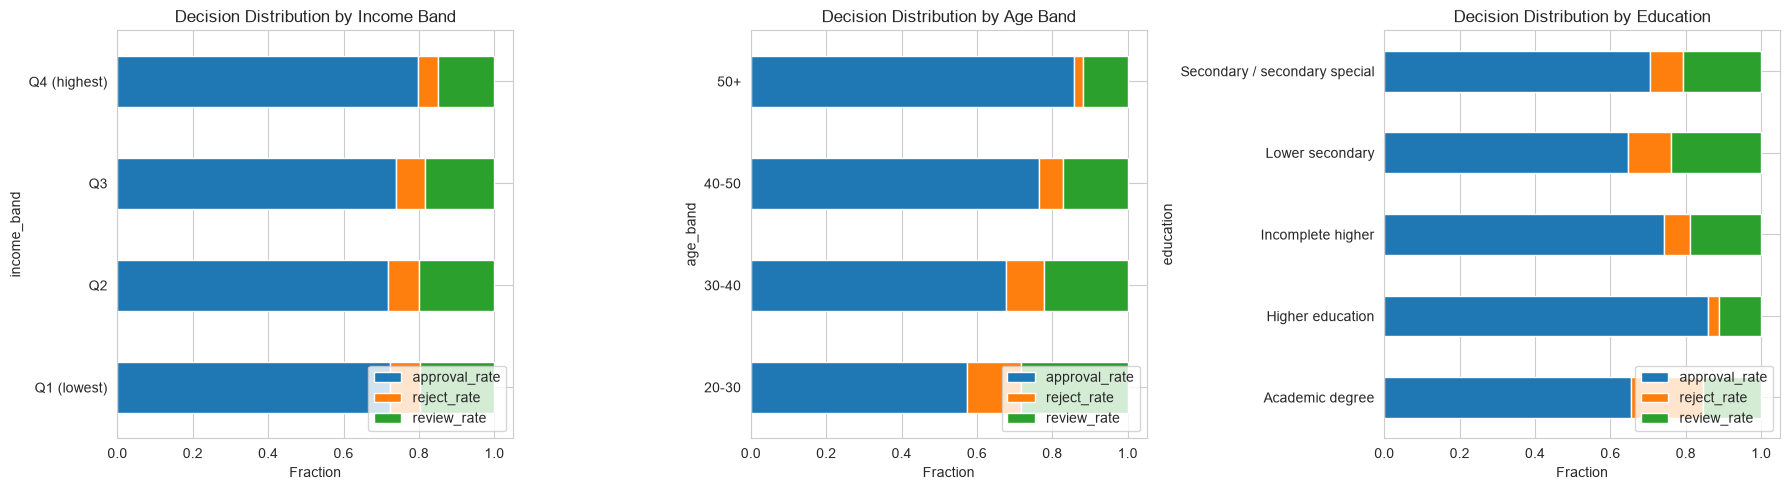

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(axes, ['income_band', 'age_band', 'education'],
                          ['Income Band', 'Age Band', 'Education']):
    g = fairness_by_group(audit_df, col)
    g[['approval_rate', 'reject_rate', 'review_rate']].plot(kind='barh', ax=ax, stacked=True)
    ax.set_title(f'Decision Distribution by {title}')
    ax.set_xlabel('Fraction')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/fairness_audit.png', dpi=100, bbox_inches='tight')
plt.show()